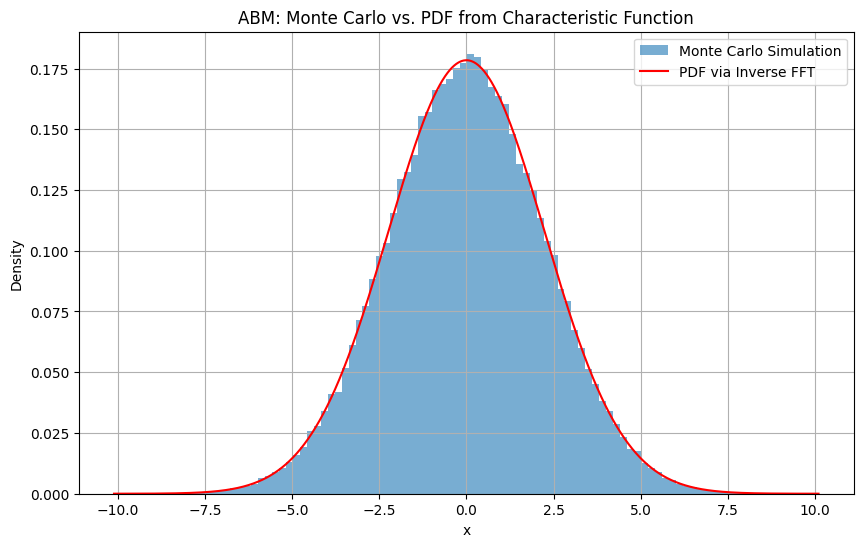

In [100]:
import numpy as np
from numpy.fft import fftshift, ifft, ifftshift
import matplotlib.pyplot as plt

# Parameters for ABM
N = 2024        # Number of grid points
Dx = 0.01       # Grid spacing in real space
Lx = N * Dx     # Total length in real space
Dxi = 2 * np.pi / Lx  # Grid spacing in frequency space
x = Dx * np.arange(-N/2, N/2)  # Real-space grid (centered)
xi = Dxi * np.arange(-N/2, N/2)  # Frequency-space grid (centered)

# ABM parameters
X0 = 0          # Initial value
mu = 0          # Drift
sigma = 1       # Volatility
t = 5.0         # Time horizon

# Define the characteristic function of ABM
def characteristic_function_ABM(u, X0, mu, sigma, t):
    """
    Computes the characteristic function of Arithmetic Brownian Motion (ABM).
    
    Parameters:
    - u: Frequency domain variable (numpy array or scalar).
    - X0: Initial value of the process.
    - mu: Drift parameter.
    - sigma: Volatility parameter.
    - t: Time horizon.
    
    Returns:
    - Characteristic function evaluated at u.
    """
    return np.exp(1j * u * X0 + 1j * u * mu * t - 0.5 * (u**2) * (sigma**2) * t)

# Compute the characteristic function in frequency space
phi = characteristic_function_ABM(xi, X0, mu, sigma, t)

# Compute the inverse FFT to get the PDF
pdf = fftshift(ifft(ifftshift(phi))).real / Dx  # Inverse FFT and scaling

# Monte Carlo simulation for ABM
n_samples = 100000  # Number of samples
np.random.seed(42)  # For reproducibility
W = np.random.normal(0, np.sqrt(t), n_samples)  # Wiener process increments
X = X0 + mu * t + sigma * W  # ABM formula

# Plot results
plt.figure(figsize=(10, 6))

# Histogram of Monte Carlo samples
plt.hist(X, bins=100, density=True, alpha=0.6, label="Monte Carlo Simulation")

# Plot PDF from inverse FFT
plt.plot(x, pdf, 'r', label="PDF via Inverse FFT")

# Labels and legend
plt.title("ABM: Monte Carlo vs. PDF from Characteristic Function")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.grid()
plt.show()